scPred-Py initialized. Remember this is a starting point!
--- Setting up environment for reproducibility ---
Ensuring directories exist: ../models and ../data/preprocessed
Directories ensured.

--- Step 1: Loading and Annotating pbmc3k Data ---
Initial raw AnnData object shape: (2700, 32738)
Initial raw AnnData .obs keys: []
Initial raw AnnData .var keys: ['gene_ids']

Generating temporary cell type labels via Louvain clustering...


/usr/lib/python3.10/functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


Full dataset (raw counts + Louvain labels) shape: (2700, 32738)
Full dataset .obs keys after labeling: ['cell_type']
Cell type distribution (all data):
 cell_type
0    1180
1     492
2     464
3     345
4     159
5      43
6      17
Name: count, dtype: int64
Data loading and labeling complete.

--- Step 2: Splitting Data ---
Data splitting complete.

--- Class Imbalance Analysis ---
Reference data class imbalance (proportion):
 cell_type
0    0.437037
1    0.182011
2    0.171958
3    0.128042
4    0.058730
5    0.015873
6    0.006349
Name: proportion, dtype: float64
Query data class imbalance (proportion):
 cell_type
0    0.437037
1    0.182716
2    0.171605
3    0.127160
4    0.059259
5    0.016049
6    0.006173
Name: proportion, dtype: float64


--- Step 4: Running Comparative Analyses on pbmc3k ---

  RUNNING EXPERIMENT: Linear SVM (Baseline)
AnnData object check passed.
--- Starting ScPred Training ---
  `perform_preprocessing` is True. Performing full internal preprocessing of ref

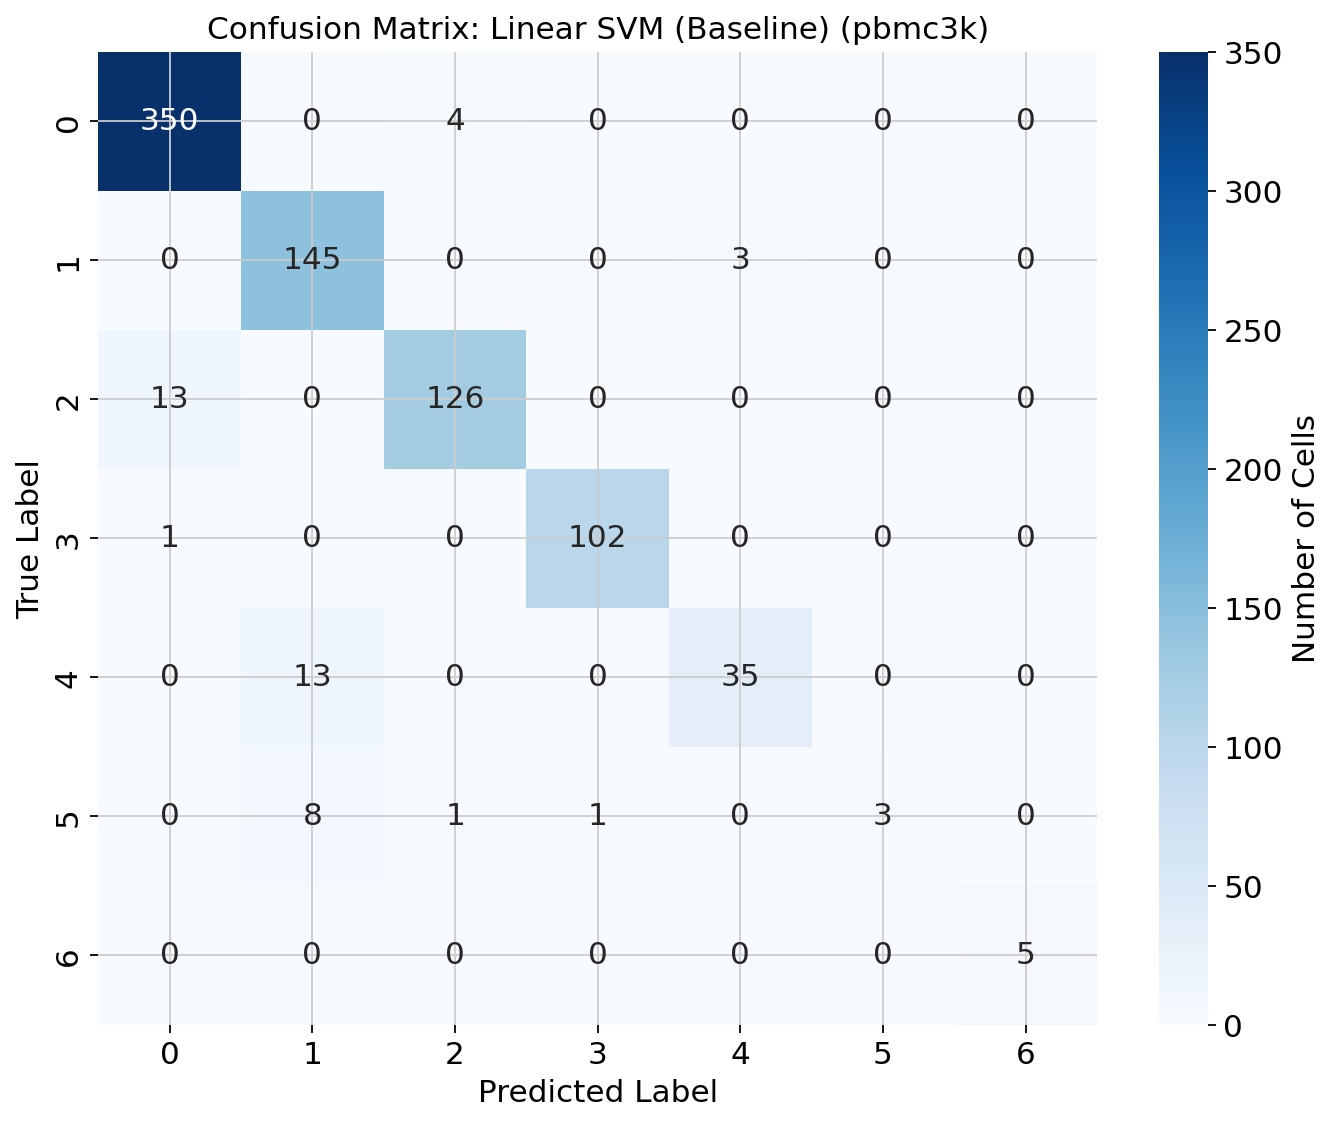


  RUNNING EXPERIMENT: RBF SVM
AnnData object check passed.
--- Starting ScPred Training ---
  `perform_preprocessing` is True. Performing full internal preprocessing of reference data...
Applying initial preprocessing (filter, normalize, log1p)...
Initial preprocessing finished.
Selecting highly variable genes with flavor='seurat'...
Selected 1000 highly variable genes.
Fitting StandardScaler on highly variable genes...
StandardScaler fitted.
Transforming data with fitted StandardScaler...
Data scaled.
Performing PCA with 30 components...
PCA finished.
Training One-vs-Rest SVM classifier with kernel='rbf', C=1.0, class_weight='None'...
Training finished.
--- ScPred Training Complete ---
AnnData object check passed.
--- Starting ScPred Prediction ---
  `perform_preprocessing` is True. Performing full internal preprocessing of query data...
Applying initial preprocessing (filter, normalize, log1p)...
Initial preprocessing finished.
Aligning 11349 genes to 1000 reference genes...
Genes a

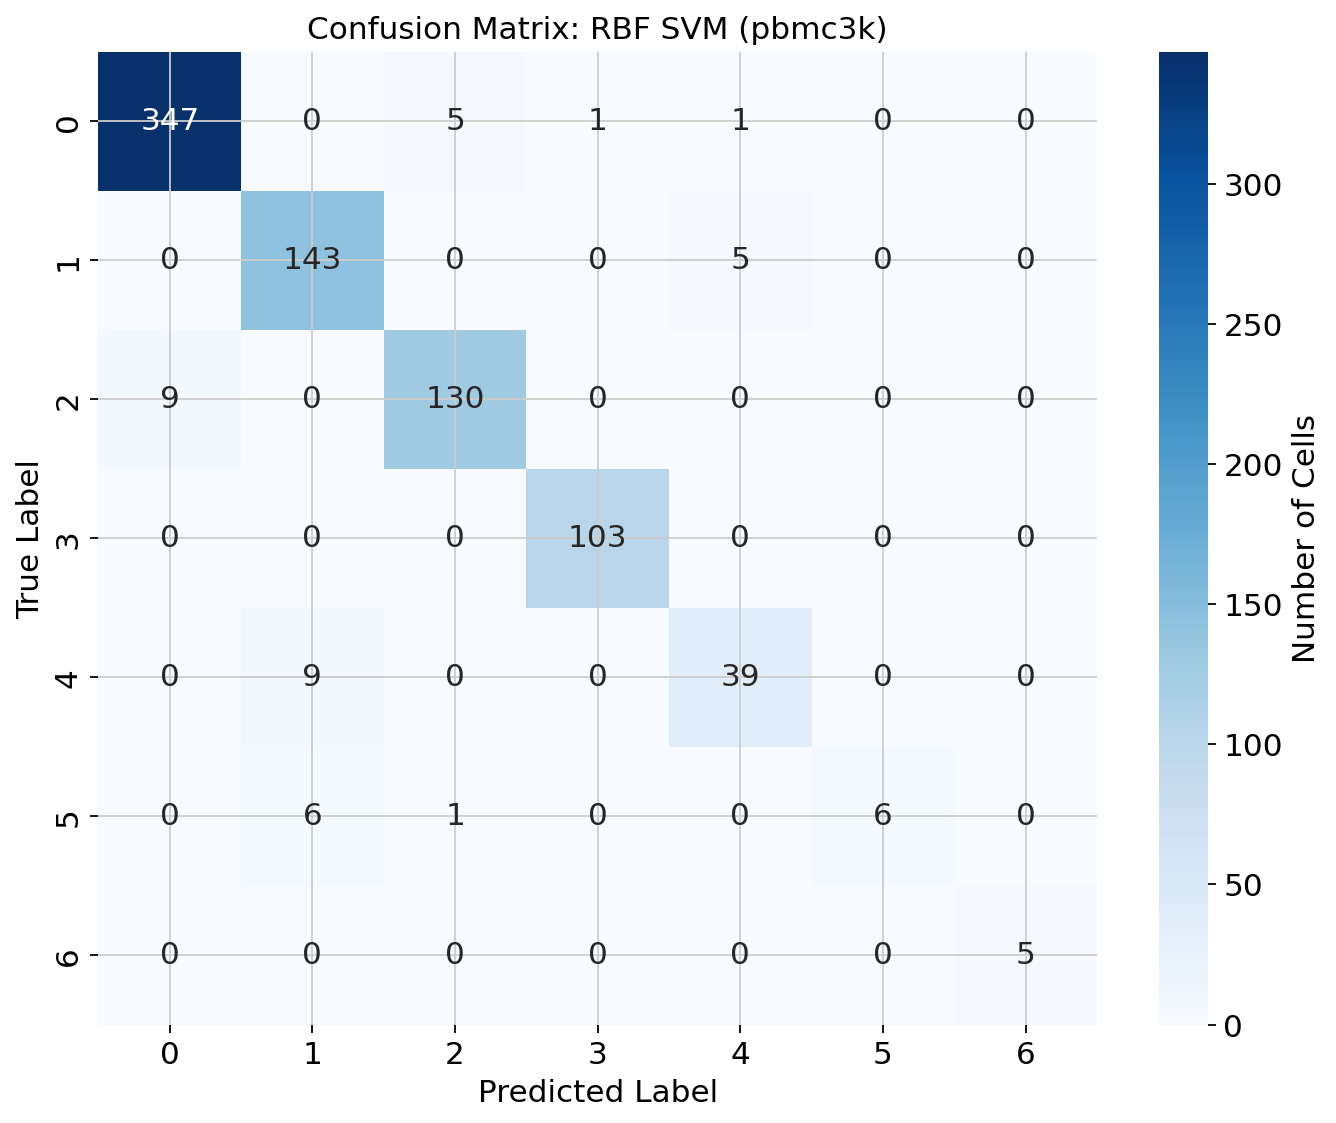


  RUNNING EXPERIMENT: RBF SVM (Balanced)
AnnData object check passed.
--- Starting ScPred Training ---
  `perform_preprocessing` is True. Performing full internal preprocessing of reference data...
Applying initial preprocessing (filter, normalize, log1p)...
Initial preprocessing finished.
Selecting highly variable genes with flavor='seurat'...
Selected 1000 highly variable genes.
Fitting StandardScaler on highly variable genes...
StandardScaler fitted.
Transforming data with fitted StandardScaler...
Data scaled.
Performing PCA with 30 components...
PCA finished.
Training One-vs-Rest SVM classifier with kernel='rbf', C=1.0, class_weight='balanced'...
Training finished.
--- ScPred Training Complete ---
AnnData object check passed.
--- Starting ScPred Prediction ---
  `perform_preprocessing` is True. Performing full internal preprocessing of query data...
Applying initial preprocessing (filter, normalize, log1p)...
Initial preprocessing finished.
Aligning 11349 genes to 1000 reference g

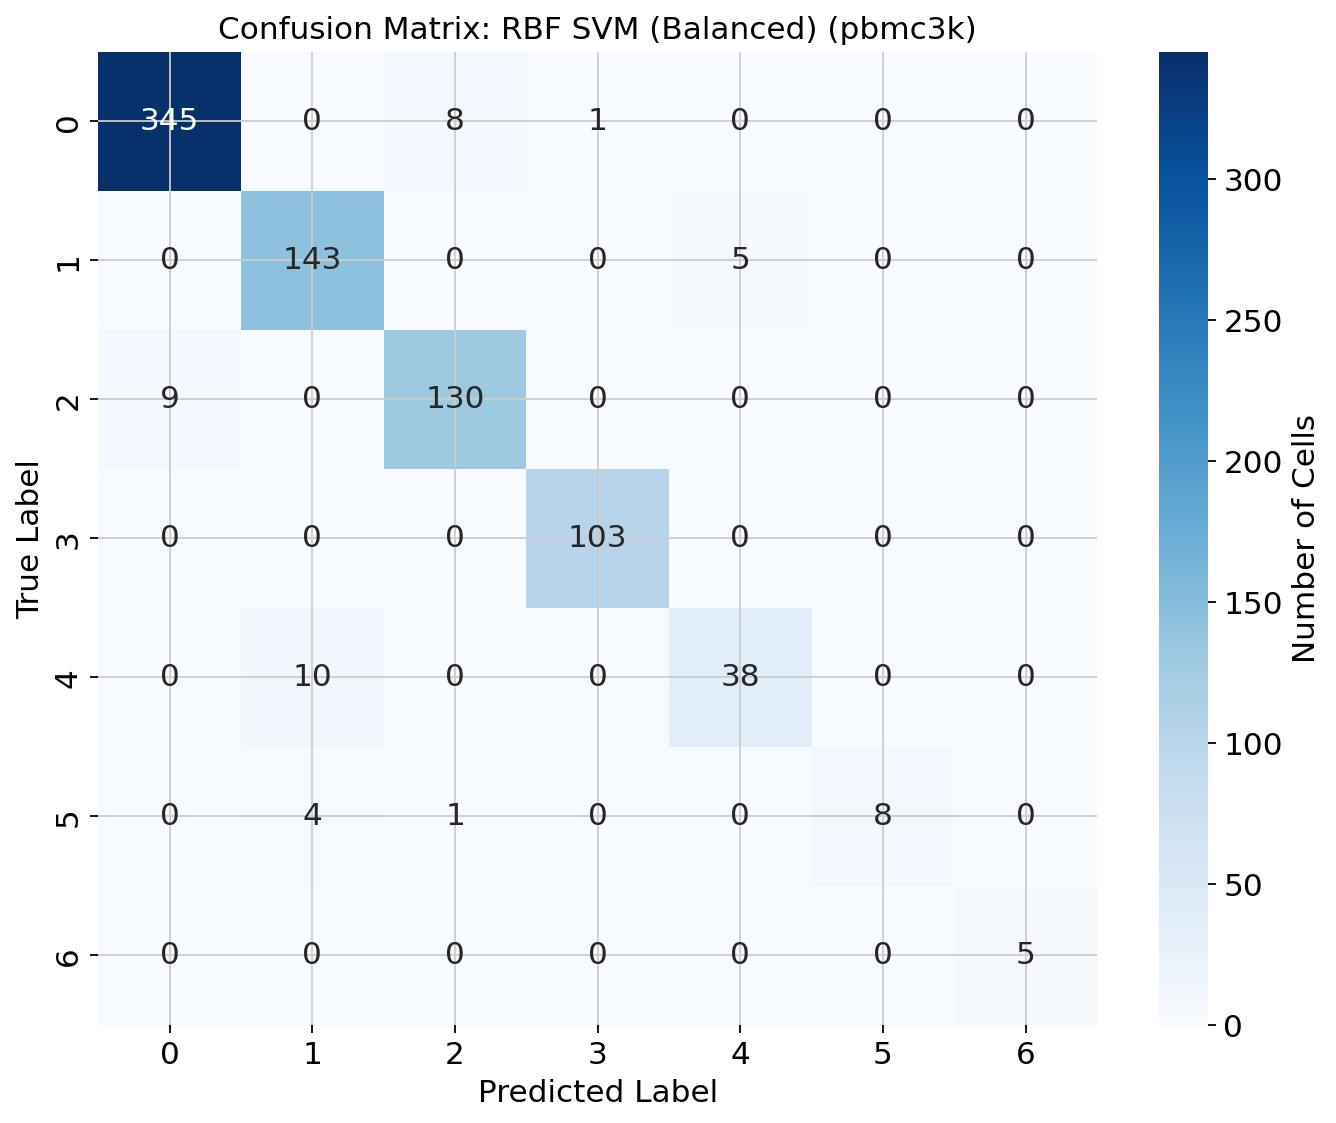



  FINAL RESULTS SUMMARY (pbmc3k)
| Experiment            |   Overall Accuracy |   Balanced Accuracy |      MCC |
|:----------------------|-------------------:|--------------------:|---------:|
| Linear SVM (Baseline) |           0.945679 |            0.832162 | 0.925209 |
| RBF SVM               |           0.954321 |            0.87939  | 0.937056 |
| RBF SVM (Balanced)    |           0.953086 |            0.897585 | 0.935377 |

--- Analysis Complete ---


In [1]:
# --- 0. Imports and Setup ---
import scanpy as sc
import anndata as ad # Explicitly import anndata
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import random

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    accuracy_score # Import accuracy_score for overall accuracy
)
from sklearn.preprocessing import LabelBinarizer

# Adjust the path to import your package
import sys
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

# Importing the main ScPredModel class and utilities
from scpred_py_final import ScPredModel # Adjusted to scpred_py_final as per your package name
from scpred_py_final import _analysis_utils # Assuming _analysis_utils is part of the package


print("--- Setting up environment for reproducibility ---")
# Set random seeds for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE) # For Python's built-in random module
# Set Scanpy's random state for operations that support it
sc.settings.set_figure_params(dpi=80, facecolor='white', figsize=(8, 8)) # Set initial figure params

# Define paths for saving (though not directly used in this comparative analysis, good practice)
MODELS_DIR = '../models'
PREPROCESSED_DATA_DIR = '../data/preprocessed'

# Create directories if they don't exist (good practice for consistency)
print(f"Ensuring directories exist: {MODELS_DIR} and {PREPROCESSED_DATA_DIR}")
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(PREPROCESSED_DATA_DIR, exist_ok=True)
print("Directories ensured.")


# --- 1. Data Loading and Initial Annotation ---
print("\n--- Step 1: Loading and Annotating pbmc3k Data ---")
adata = sc.datasets.pbmc3k()
adata.var_names_make_unique()

print(f"Initial raw AnnData object shape: {adata.shape}")
print(f"Initial raw AnnData .obs keys: {adata.obs.keys().tolist()}")
print(f"Initial raw AnnData .var keys: {adata.var.keys().tolist()}\n")


# Generate 'cell_type' labels using a temporary preprocessing pipeline
# This prepares the `adata` object with raw counts and the `cell_type` column
print("Generating temporary cell type labels via Louvain clustering...")
temp_adata_for_labels = adata.copy()
sc.pp.filter_cells(temp_adata_for_labels, min_genes=200)
sc.pp.filter_genes(temp_adata_for_labels, min_cells=3)
sc.pp.normalize_total(temp_adata_for_labels, target_sum=1e4)
sc.pp.log1p(temp_adata_for_labels)
# Using default HVG parameters for initial labeling, consistent with ScPredModel's defaults
sc.pp.highly_variable_genes(temp_adata_for_labels, flavor='seurat') # Use 'seurat' flavor
temp_adata_hvg_for_labels = temp_adata_for_labels[:, temp_adata_for_labels.var.highly_variable].copy()
sc.pp.scale(temp_adata_hvg_for_labels, max_value=10)
sc.tl.pca(temp_adata_hvg_for_labels, random_state=RANDOM_STATE) # Added random_state
sc.pp.neighbors(temp_adata_hvg_for_labels, random_state=RANDOM_STATE) # Added random_state
sc.tl.louvain(temp_adata_hvg_for_labels, random_state=RANDOM_STATE, key_added='cell_type') # Added random_state

# Assign the generated cell_type labels back to the original raw adata object
adata.obs['cell_type'] = temp_adata_hvg_for_labels.obs['cell_type'].reindex(adata.obs_names).astype('category') # Ensure category type

print(f"Full dataset (raw counts + Louvain labels) shape: {adata.shape}")
print(f"Full dataset .obs keys after labeling: {adata.obs.keys().tolist()}")
print("Cell type distribution (all data):\n", adata.obs['cell_type'].value_counts())
print("Data loading and labeling complete.")


# --- 2. Train-Test Split ---
print("\n--- Step 2: Splitting Data ---")
indices = range(adata.n_obs)
ref_idx, query_idx = train_test_split(
    indices, test_size=0.3, random_state=RANDOM_STATE, stratify=adata.obs['cell_type']
)
ref_adata_raw = adata[ref_idx, :].copy()
query_adata_raw = adata[query_idx, :].copy()
print("Data splitting complete.")


# Calculate and report class imbalance
print("\n--- Class Imbalance Analysis ---")
print("Reference data class imbalance (proportion):\n", ref_adata_raw.obs['cell_type'].value_counts(normalize=True).sort_index())
print("Query data class imbalance (proportion):\n", query_adata_raw.obs['cell_type'].value_counts(normalize=True).sort_index())


# --- 3. Define the Experiment Runner Function ---
def run_scpred_experiment(experiment_name, ref_data, query_data, svm_params, prediction_threshold=0.0):
    """
    A helper function to run a single scPred experiment with given parameters.
    Includes prediction threshold and passes probabilities for ROC AUC.
    """
    print("\n" + "="*50)
    print(f"  RUNNING EXPERIMENT: {experiment_name}")
    print("="*50)
    
    # --- Train Model ---
    model = ScPredModel()
    model.train(
        ref_adata=ref_data,
        cell_type_key='cell_type',
        n_components=30,
        hvg_n_top_genes=1000, # Using 1000 HVGs consistently for comparison
        hvg_flavor='seurat',  # Using 'seurat' flavor consistently
        **svm_params          # Pass all SVM parameters including class_weight
    )
    
    # --- Predict ---
    query_pred = model.predict(query_data, threshold=prediction_threshold)
    
    # --- Evaluate ---
    true_labels = query_pred.obs['cell_type']
    predicted_labels = query_pred.obs['scpred_prediction']
    
    # Calculate overall accuracy (including 'unassigned' as a potential prediction)
    overall_accuracy_score = accuracy_score(true_labels, predicted_labels)
    print(f"Overall Accuracy (including 'unassigned'): {overall_accuracy_score:.4f}")

    # Extract prediction probabilities for ROC AUC
    # Ensure these columns exist before trying to copy
    prob_cols = [col for col in query_pred.obs.columns if col.startswith('scpred_prob_')]
    y_pred_probs_df = None
    if prob_cols: # Check if the list is not empty
        y_pred_probs_df = query_pred.obs[prob_cols].copy()

    print(f"\n--- Results for: {experiment_name} ---")
    
    # Use the analysis util for the full report, passing y_pred_probs for ROC AUC
    metrics = _analysis_utils.evaluate_and_report_metrics(
        true_labels=true_labels,
        predicted_labels=predicted_labels,
        classifier_classes=model.classifier_.classes_, # Pass classifier classes
        y_pred_probs=y_pred_probs_df # Pass probabilities
    )
    
    # --- Visualize Confusion Matrix ---
    # Ensure labels are string type consistently, including "unassigned" if present
    true_labels_str = true_labels.astype(str)
    predicted_labels_str = predicted_labels.astype(str)

    # Ensure all unique labels (true and predicted, including 'unassigned') are used for CM labels
    cm_labels_str = sorted(list(set(true_labels_str.unique()) | set(predicted_labels_str.unique())))
    cm = confusion_matrix(true_labels_str, predicted_labels_str, labels=cm_labels_str)
    cm_df = pd.DataFrame(cm, index=cm_labels_str, columns=cm_labels_str)
    
    plt.figure(figsize=(10, 8)) # Slightly larger figure for clarity with potentially more labels
    sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar_kws={'label': 'Number of Cells'})
    plt.title(f'Confusion Matrix: {experiment_name} (pbmc3k)')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()
    
    return {
        "Experiment": experiment_name,
        "Overall Accuracy": overall_accuracy_score, # Now correctly included
        "Balanced Accuracy": metrics.get('balanced_accuracy', np.nan),
        "MCC": metrics.get('mcc', np.nan),
        "ROC AUC Scores": metrics.get('roc_auc_scores', {}) # Include ROC AUC scores
    }

# --- 4. Run Comparative Experiments ---
print("\n\n--- Step 4: Running Comparative Analyses on pbmc3k ---")

experiments_to_run = {
    "Linear SVM (Baseline)": {
        'svm_kernel': 'linear', 'svm_c': 1.0, 'svm_random_state': RANDOM_STATE, 'svm_class_weight': None
    },
    "RBF SVM": {
        'svm_kernel': 'rbf', 'svm_c': 1.0, 'svm_random_state': RANDOM_STATE, 'svm_class_weight': None
    },
    "RBF SVM (Balanced)": {
        'svm_kernel': 'rbf', 'svm_c': 1.0, 'svm_random_state': RANDOM_STATE, 'svm_class_weight': 'balanced'
    }
}

results_list = []
for name, params in experiments_to_run.items():
    # Pass copies of raw data to ensure each experiment starts fresh
    result = run_scpred_experiment(name, ref_adata_raw.copy(), query_adata_raw.copy(), params)
    results_list.append(result)

# --- 5. Summarize Results ---
print("\n\n" + "="*50)
print("  FINAL RESULTS SUMMARY (pbmc3k)")
print("="*50)

results_df = pd.DataFrame(results_list)
# Display ROC AUC scores separately or as a nested dict if desired
# For a clean markdown table, we'll just show the main metrics.
# You can inspect results_list for the full ROC AUC dicts.
print(results_df[['Experiment', 'Overall Accuracy', 'Balanced Accuracy', 'MCC']].to_markdown(index=False))

print("\n--- Analysis Complete ---")